# House Price Prediction using Linear Regression

This project uses the California Housing dataset to build and evaluate a Linear Regression model for predicting house prices.

In [1]:
import sklearn

print(sklearn.__version__)

1.8.0


## Import libraries

In [2]:
# Basic libraries for data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Dataset

In [3]:
# Loading California Housing dataset from sklearn
data = fetch_california_housing(as_frame=True)

# Combining features and target into one dataframe
df = pd.concat([data.data, data.target.rename("MedHouseVal")], axis=1)

# Display first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Data Exploration

In [4]:
# Checking dataset shape
print("Dataset Shape:", df.shape)

# Displaying column names
print("\nColumns in Dataset:\n")
print(df.columns)

Dataset Shape: (20640, 9)

Columns in Dataset:

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')


In [5]:
# Basic information about dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
# Checking for missing values
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [7]:
# Statistical summary of dataset
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Data Visualization

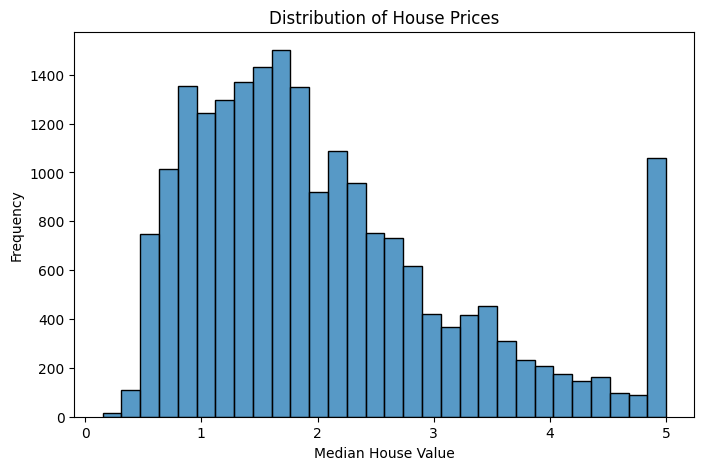

In [8]:
# Plotting distribution of house prices

plt.figure(figsize=(8,5))

sns.histplot(df["MedHouseVal"], bins=30)

plt.title("Distribution of House Prices")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")

plt.show()

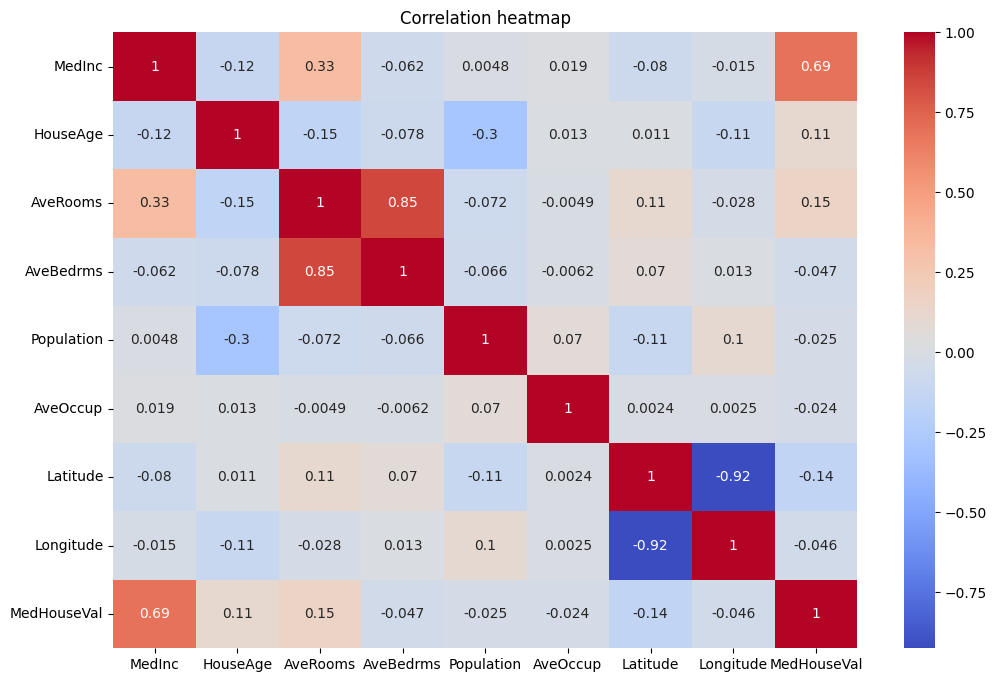

In [9]:
# correlation heatmap to understand relationships between features

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap= "coolwarm")
plt.title("Correlation heatmap")
plt.show()

## Train-Test Split

In [10]:
# Separating features and target variable

X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

# Splitting dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (16512, 8)
Testing Data Shape: (4128, 8)


## Model Training

In [11]:
# Creating Linear Regression model

model = LinearRegression()

# Training model using training data

model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


## Predictions

In [12]:
# Predicting house prices using test data

y_pred = model.predict(X_test)

# Displaying first few predictions

predictions = pd.DataFrame({
    "Actual Value": y_test.values,
    "Predicted Value": y_pred
})

predictions.head()

,Actual Value,Predicted Value
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657


## Evaluation Metrics

In [13]:
# Calculating evaluation metrics

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

# Printing results

print("Model Evaluation Metrics\n")

print(f"Mean Absolute Error (MAE): {mae:.3f}")

print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")

print(f"R2 Score: {r2:.3f}")

Model Evaluation Metrics

Mean Absolute Error (MAE): 0.533
Root Mean Squared Error (RMSE): 0.746
R2 Score: 0.576


## Visualization

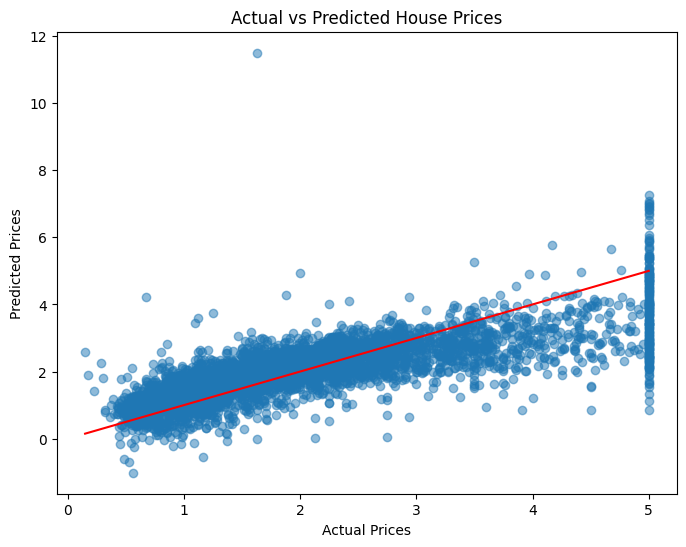

In [14]:
# Plotting Actual vs Predicted values

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

# Reference line for ideal predictions

plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    color='red'
)

plt.show()

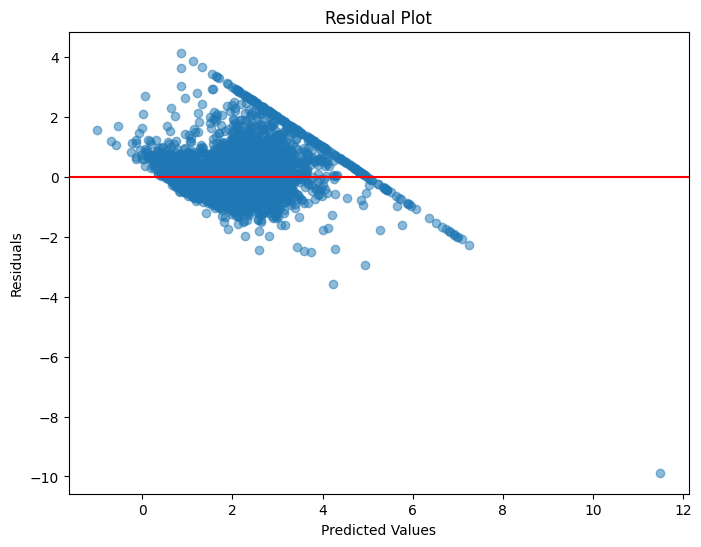

In [15]:
# Residual plot to check prediction errors

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(y=0, color='red')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

## Conclusion

In this project, a Linear Regression model was built using the California Housing dataset to predict house prices.

The model was trained and evaluated using metrics like MAE(mean absolute error), RMSE(root mean squared error), and R²(r-squared score). The visualizations helped in understanding the relationship between actual and predicted values.

The model gives decent predictions, but performance can be improved further using advanced algorithms and feature engineering techniques.